# 03 — Exploratory Data Analysis

## Objective

This notebook performs an in-depth Exploratory Data Analysis (EDA) of the Criteo Uplift dataset.

The objectives are:

- Understand the distribution of customer-level features
- Analyze treatment and control groups
- Study conversion and visit behavior
- Analyze exposure patterns
- Identify relationships between features and outcomes
- Analyze treatment heterogeneity
- Detect important patterns for downstream churn and uplift modeling
- Generate business-oriented insights

The analysis uses a representative sample for visualization because the original dataset contains millions of observations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\raw\criteo-research-uplift-v2.1.csv.gz"
)

print("Dataset exists:", DATA_PATH.exists())
print("Dataset size (MB):", round(DATA_PATH.stat().st_size / (1024 ** 2), 2))

Dataset exists: True
Dataset size (MB): 297.0


In [3]:
SAMPLE_SIZE = 100_000

df = pd.read_csv(
    DATA_PATH,
    compression="gzip",
    nrows=SAMPLE_SIZE
)

print("Sample shape:", df.shape)
df.head()

Sample shape: (100000, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Rows: 100000
Columns: 16

Columns:
['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
f0,100000.000000,21.598848,4.604217,12.616365,20.599416,22.959279,24.667063,26.745092
f1,100000.000000,10.067764,0.099210,10.059654,10.059654,10.059654,10.059654,14.560990
f2,100000.000000,8.346235,0.256821,8.214383,8.214383,8.214383,8.231230,9.051956
f3,100000.000000,4.348703,1.131443,-6.314955,4.679882,4.679882,4.679882,4.679882
f4,100000.000000,10.363419,0.463894,10.280525,10.280525,10.280525,10.280525,20.036060
f5,100000.000000,4.034308,0.421120,-6.729900,4.115453,4.115453,4.115453,4.115453
f6,100000.000000,-4.478084,4.147827,-25.860481,-6.699321,-3.282109,-1.288207,0.294443
f7,100000.000000,5.091506,1.186038,4.833815,4.833815,4.833815,4.833815,11.995830
f8,100000.000000,3.952916,0.042551,3.640858,3.955396,3.971858,3.971858,3.971858
f9,100000.000000,14.419157,4.676643,13.190056,13.190056,13.190056,13.190056,67.419043


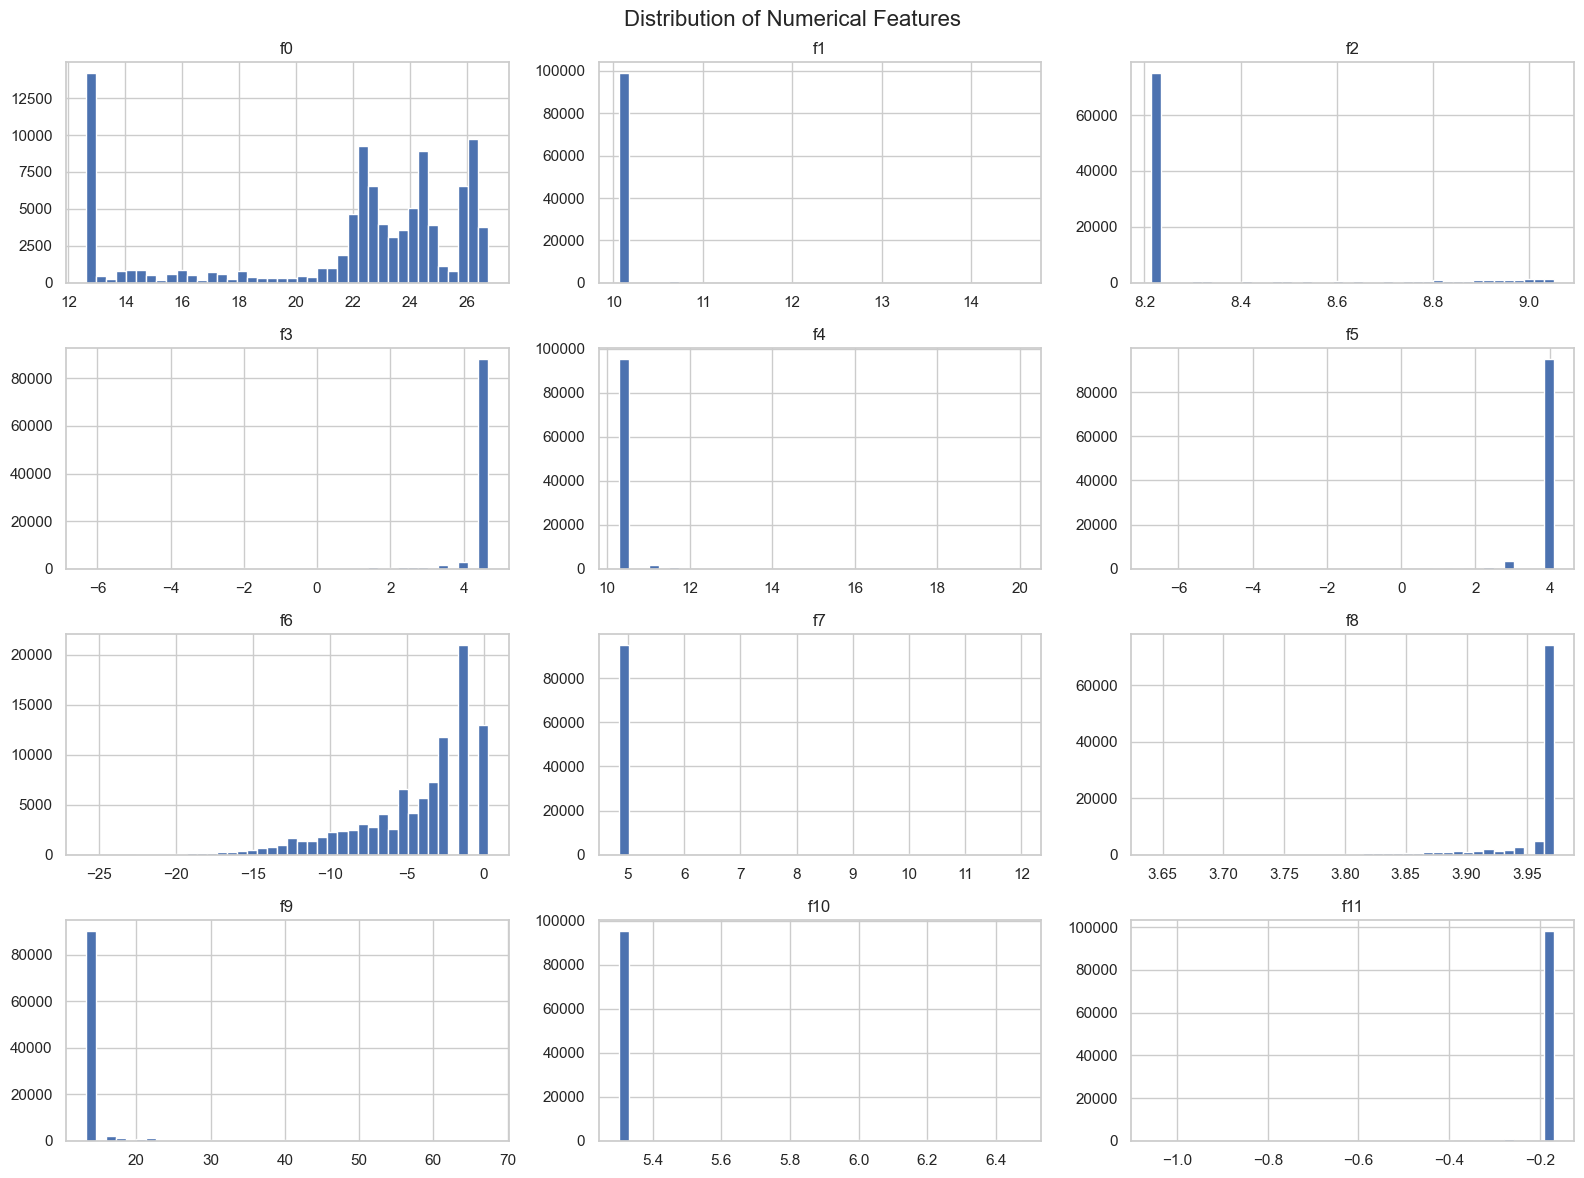

In [6]:
feature_cols = [f"f{i}" for i in range(12)]

df[feature_cols].hist(
    figsize=(16, 12),
    bins=40
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

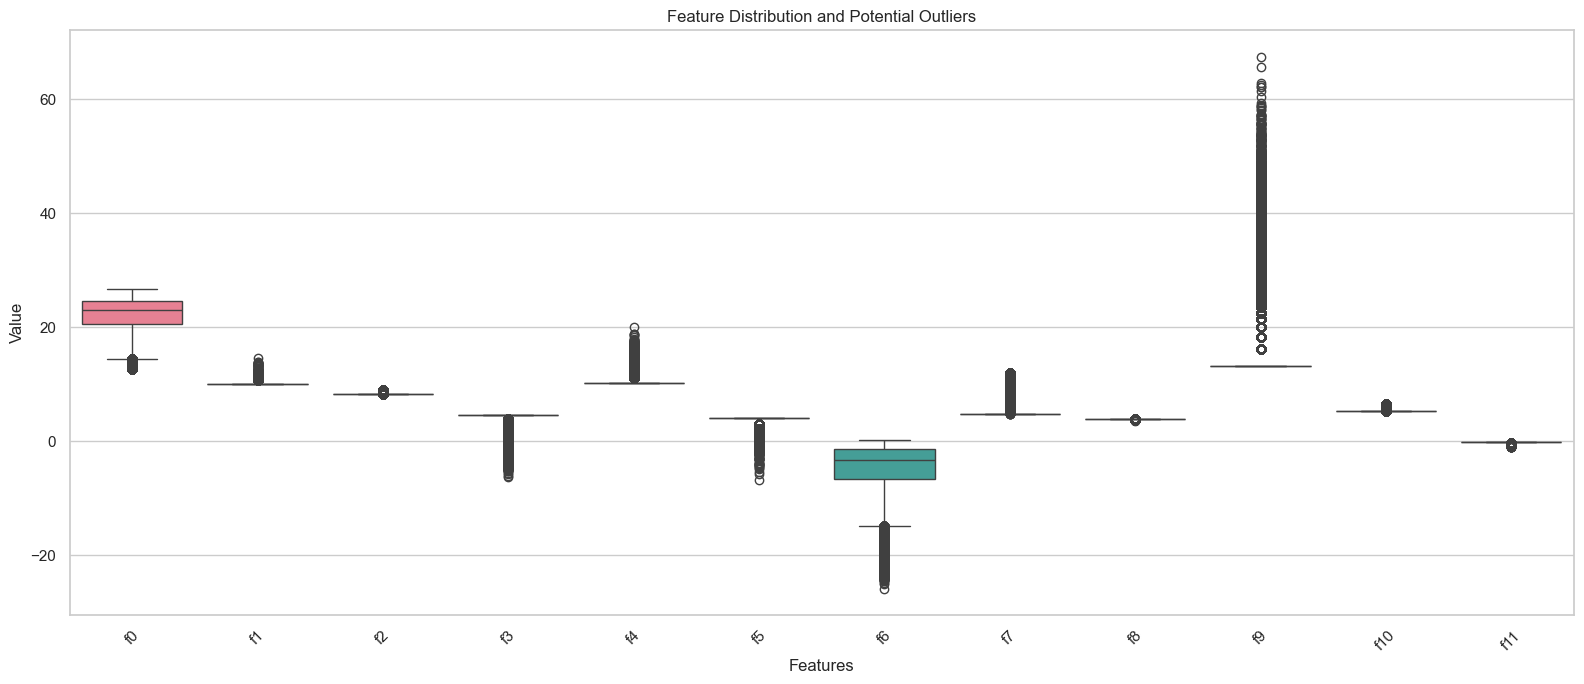

In [7]:
plt.figure(figsize=(16, 7))

sns.boxplot(data=df[feature_cols])

plt.title("Feature Distribution and Potential Outliers")
plt.xlabel("Features")
plt.ylabel("Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

treatment
1    100000
Name: count, dtype: int64


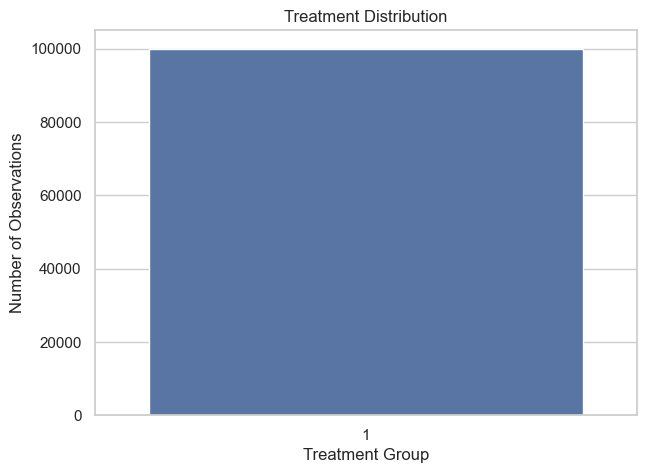

In [8]:
treatment_counts = df["treatment"].value_counts().sort_index()

print(treatment_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=treatment_counts.index.astype(str),
    y=treatment_counts.values
)

plt.title("Treatment Distribution")
plt.xlabel("Treatment Group")
plt.ylabel("Number of Observations")

plt.show()

In [9]:
treatment_percentage = (
    df["treatment"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Treatment distribution (%):")
print(treatment_percentage)

Treatment distribution (%):
treatment
1   100.000000
Name: proportion, dtype: float64


conversion
0    99494
1      506
Name: count, dtype: int64


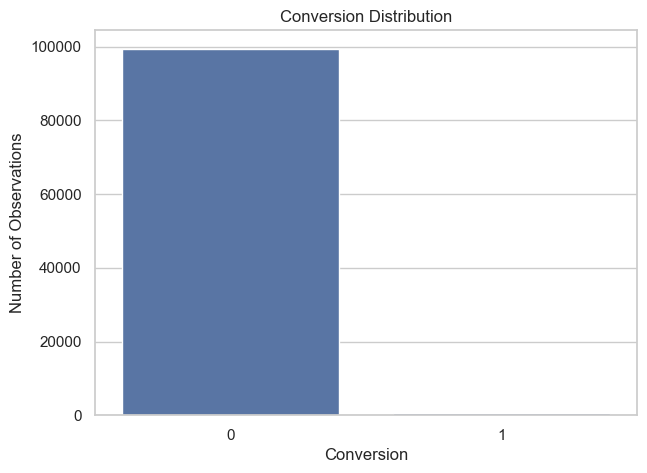

In [10]:
conversion_counts = df["conversion"].value_counts().sort_index()

print(conversion_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=conversion_counts.index.astype(str),
    y=conversion_counts.values
)

plt.title("Conversion Distribution")
plt.xlabel("Conversion")
plt.ylabel("Number of Observations")

plt.show()

visit
0    97486
1     2514
Name: count, dtype: int64


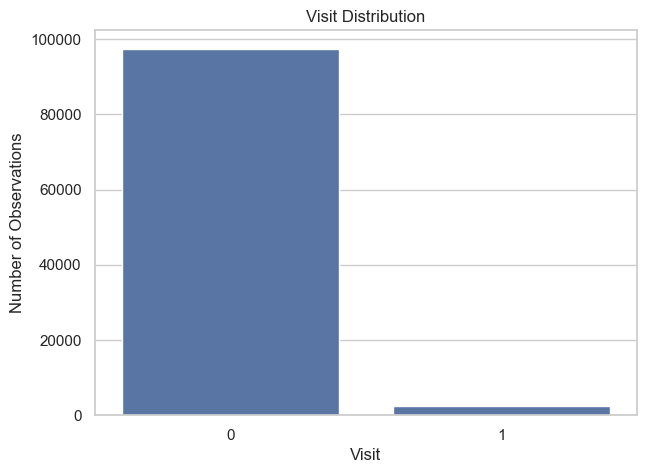

In [11]:
visit_counts = df["visit"].value_counts().sort_index()

print(visit_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=visit_counts.index.astype(str),
    y=visit_counts.values
)

plt.title("Visit Distribution")
plt.xlabel("Visit")
plt.ylabel("Number of Observations")

plt.show()

exposure
0    97390
1     2610
Name: count, dtype: int64


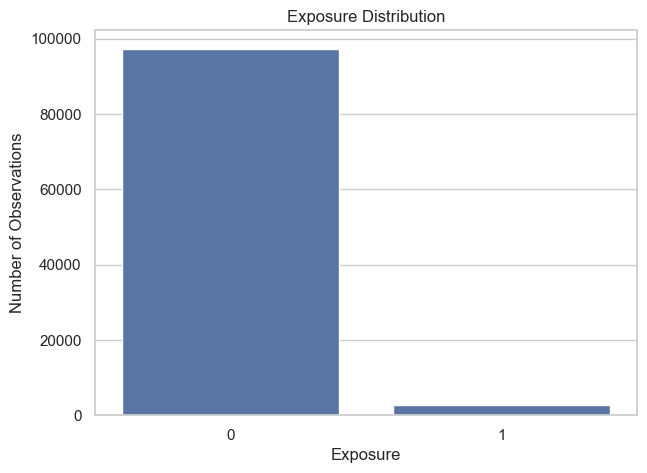

In [12]:
exposure_counts = df["exposure"].value_counts().sort_index()

print(exposure_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=exposure_counts.index.astype(str),
    y=exposure_counts.values
)

plt.title("Exposure Distribution")
plt.xlabel("Exposure")
plt.ylabel("Number of Observations")

plt.show()

In [13]:
conversion_by_treatment = (
    df.groupby("treatment")["conversion"]
    .mean()
)

print("Conversion rate by treatment:")
print(conversion_by_treatment)

Conversion rate by treatment:
treatment
1   0.005060
Name: conversion, dtype: float64


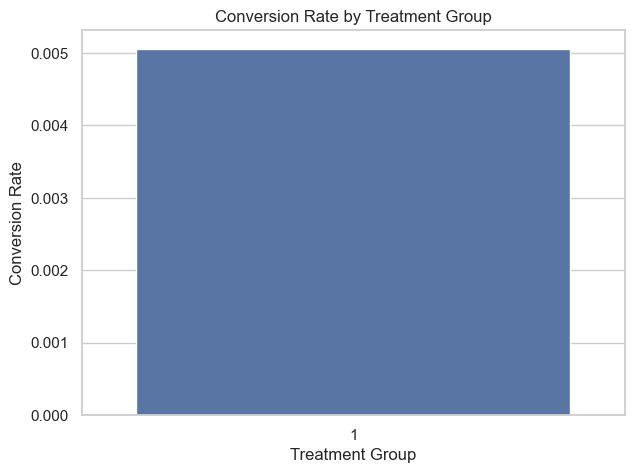

In [14]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=conversion_by_treatment.index.astype(str),
    y=conversion_by_treatment.values
)

plt.title("Conversion Rate by Treatment Group")
plt.xlabel("Treatment Group")
plt.ylabel("Conversion Rate")

plt.show()

Exposure rate by treatment:
treatment
1   0.026100
Name: exposure, dtype: float64


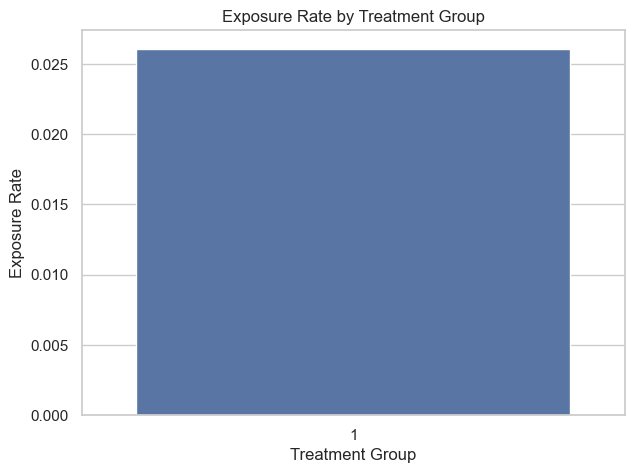

In [19]:
exposure_by_treatment = (
    df.groupby("treatment")["exposure"]
    .mean()
)

print("Exposure rate by treatment:")
print(exposure_by_treatment)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=exposure_by_treatment.index.astype(str),
    y=exposure_by_treatment.values
)

plt.title("Exposure Rate by Treatment Group")
plt.xlabel("Treatment Group")
plt.ylabel("Exposure Rate")

plt.show()

In [32]:
SAMPLE_SIZE = 100_000

# Load the full dataset
full_df = pd.read_csv(
    DATA_PATH,
    compression="gzip"
)

# Take a random sample from the entire dataset
df = (
    full_df.sample(n=SAMPLE_SIZE, random_state=42)
           .reset_index(drop=True)
)

print(df["treatment"].value_counts())

treatment
1    85037
0    14963
Name: count, dtype: int64


In [33]:
conversion_by_treatment = (
    df.groupby("treatment")["conversion"]
      .mean()
)

print(conversion_by_treatment)

treatment
0   0.001738
1   0.003328
Name: conversion, dtype: float64


In [34]:
control_conversion = conversion_by_treatment.loc[0]
treatment_conversion = conversion_by_treatment.loc[1]

observed_conversion_lift = (
    treatment_conversion - control_conversion
)

relative_lift = (
    observed_conversion_lift / control_conversion * 100
)

print(f"Control conversion rate: {control_conversion:.6f}")
print(f"Treatment conversion rate: {treatment_conversion:.6f}")
print(f"Observed absolute lift: {observed_conversion_lift:.6f}")
print(f"Observed relative lift: {relative_lift:.2f}%")

Control conversion rate: 0.001738
Treatment conversion rate: 0.003328
Observed absolute lift: 0.001590
Observed relative lift: 91.52%


Visit rate by treatment:
treatment
0   0.039230
1   0.048979
Name: visit, dtype: float64


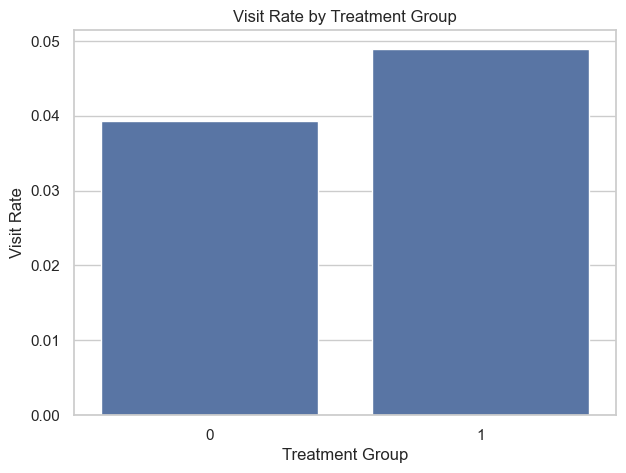

In [35]:
visit_by_treatment = (
    df.groupby("treatment")["visit"]
    .mean()
)

print("Visit rate by treatment:")
print(visit_by_treatment)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=visit_by_treatment.index.astype(str),
    y=visit_by_treatment.values
)

plt.title("Visit Rate by Treatment Group")
plt.xlabel("Treatment Group")
plt.ylabel("Visit Rate")

plt.show()

Exposure rate by treatment:
treatment
0   0.000000
1   0.036972
Name: exposure, dtype: float64


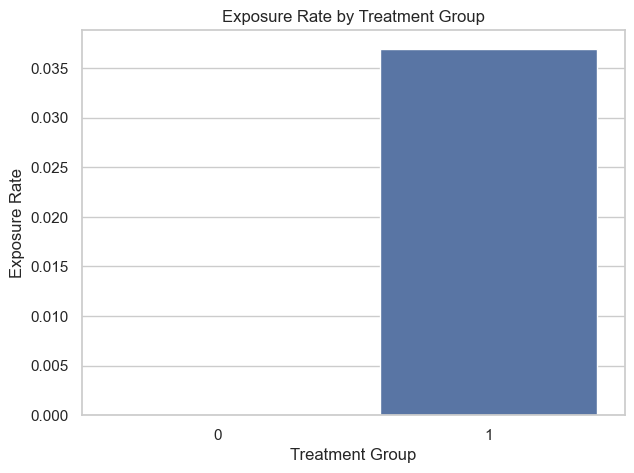

In [36]:
exposure_by_treatment = (
    df.groupby("treatment")["exposure"]
    .mean()
)

print("Exposure rate by treatment:")
print(exposure_by_treatment)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=exposure_by_treatment.index.astype(str),
    y=exposure_by_treatment.values
)

plt.title("Exposure Rate by Treatment Group")
plt.xlabel("Treatment Group")
plt.ylabel("Exposure Rate")

plt.show()

exposure
0   0.001156
1   0.062659
Name: conversion, dtype: float64


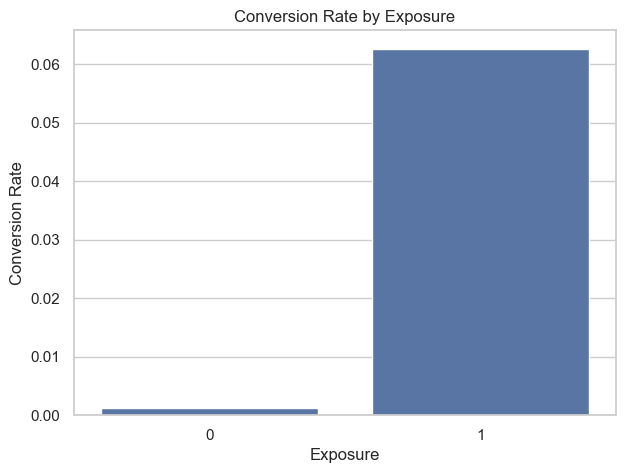

In [37]:
conversion_by_exposure = (
    df.groupby("exposure")["conversion"]
    .mean()
)

print(conversion_by_exposure)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=conversion_by_exposure.index.astype(str),
    y=conversion_by_exposure.values
)

plt.title("Conversion Rate by Exposure")
plt.xlabel("Exposure")
plt.ylabel("Conversion Rate")

plt.show()

Conversion rate by visit status:
visit
0   0.000000
1   0.065025
Name: conversion, dtype: float64


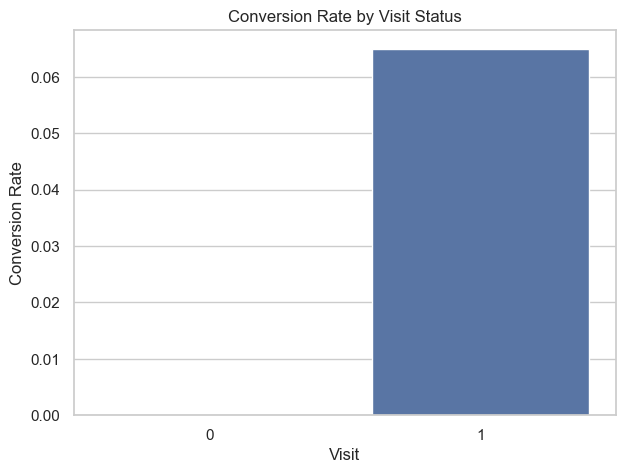

In [38]:
visit_conversion = (
    df.groupby("visit")["conversion"]
    .mean()
)

print("Conversion rate by visit status:")
print(visit_conversion)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=visit_conversion.index.astype(str),
    y=visit_conversion.values
)

plt.title("Conversion Rate by Visit Status")
plt.xlabel("Visit")
plt.ylabel("Conversion Rate")

plt.show()

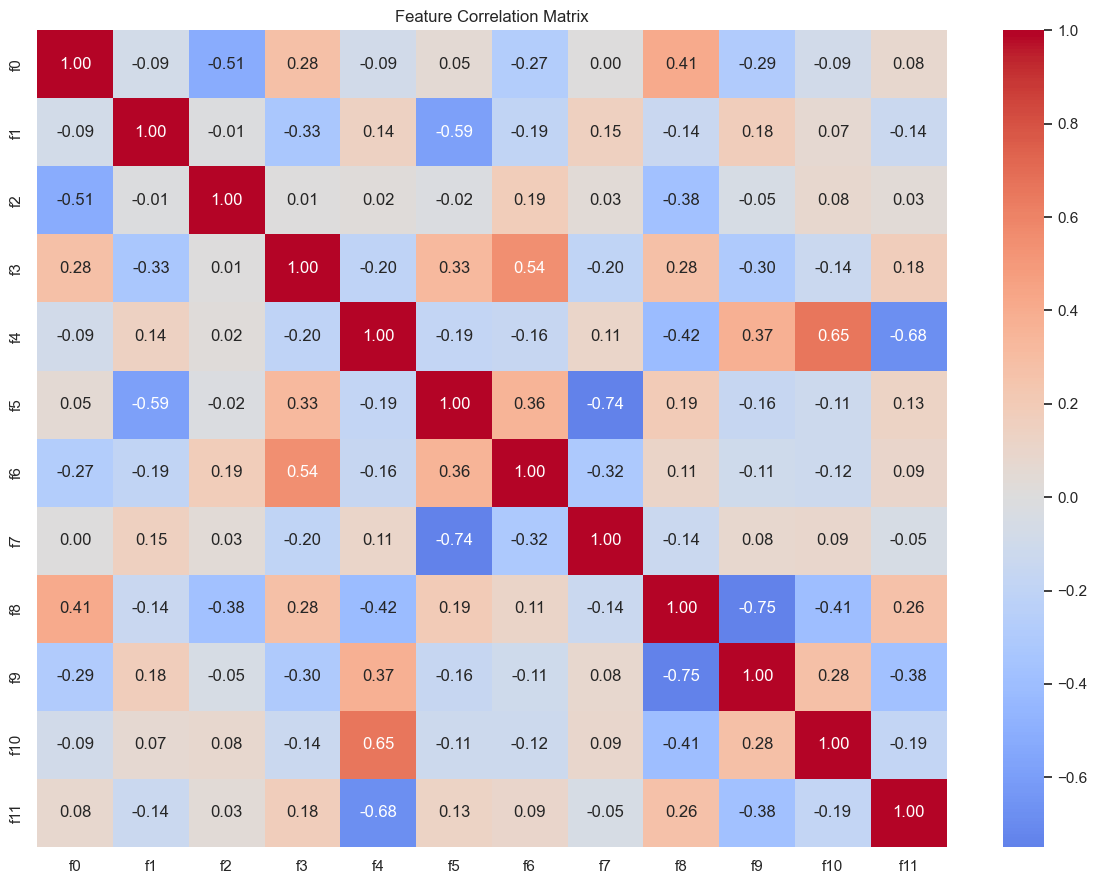

In [39]:
correlation_matrix = df[feature_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [40]:
conversion_correlations = (
    df[feature_cols + ["conversion"]]
    .corr()["conversion"]
    .drop("conversion")
    .sort_values()
)

print(conversion_correlations)

f11   -0.300668
f8    -0.135482
f3    -0.119082
f5    -0.091346
f6    -0.084759
f0    -0.040341
f2    -0.016311
f7     0.045522
f1     0.073568
f10    0.106898
f9     0.158591
f4     0.307424
Name: conversion, dtype: float64


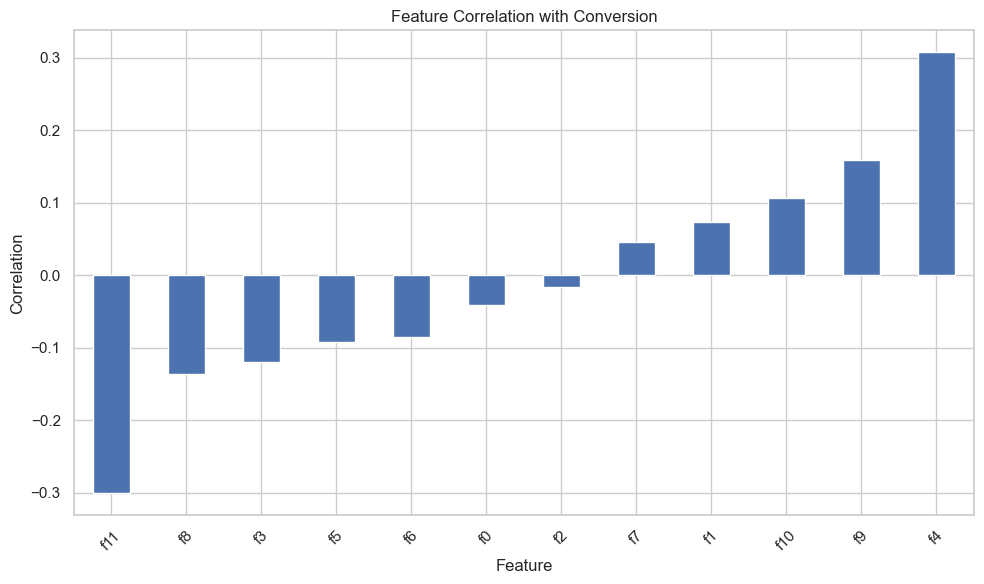

In [41]:
plt.figure(figsize=(10, 6))

conversion_correlations.plot(kind="bar")

plt.title("Feature Correlation with Conversion")
plt.xlabel("Feature")
plt.ylabel("Correlation")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
feature = "f0"

df["f0_bin"] = pd.qcut(
    df[feature],
    q=5,
    duplicates="drop"
)

heterogeneity = (
    df.groupby(["f0_bin", "treatment"], observed=True)["conversion"]
    .mean()
    .unstack()
)

heterogeneity.columns = [
    "control_conversion",
    "treatment_conversion"
]

heterogeneity["uplift"] = (
    heterogeneity["treatment_conversion"]
    - heterogeneity["control_conversion"]
)

heterogeneity

,control_conversion,treatment_conversion,uplift
f0_bin,,,
"(12.615, 18.211]",0.003379,0.006514,0.003135
"(18.211, 22.781]",0.000984,0.002360,0.001376
"(22.781, 24.839]",0.000337,0.000822,0.000485
"(24.839, 26.745]",0.000661,0.000412,-0.000249


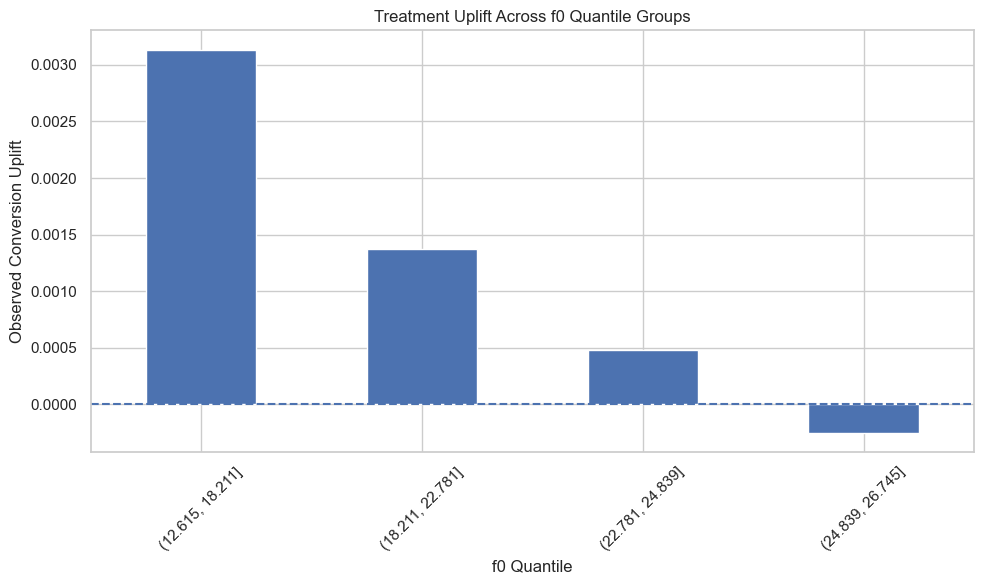

In [43]:
plt.figure(figsize=(10, 6))

heterogeneity["uplift"].plot(
    kind="bar"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Treatment Uplift Across f0 Quantile Groups")
plt.xlabel("f0 Quantile")
plt.ylabel("Observed Conversion Uplift")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
heterogeneity_summary = []

for feature in feature_cols:

    temp = df[[feature, "treatment", "conversion"]].copy()

    temp["bin"] = pd.qcut(
        temp[feature],
        q=5,
        duplicates="drop"
    )

    grouped = (
        temp.groupby(["bin", "treatment"], observed=True)["conversion"]
        .mean()
        .unstack()
    )

    if 0 in grouped.columns and 1 in grouped.columns:

        uplift_values = (
            grouped[1] - grouped[0]
        ).dropna()

        heterogeneity_summary.append({
            "feature": feature,
            "min_uplift": uplift_values.min(),
            "max_uplift": uplift_values.max(),
            "uplift_range": (
                uplift_values.max() -
                uplift_values.min()
            ),
            "mean_uplift": uplift_values.mean()
        })

heterogeneity_summary_df = pd.DataFrame(
    heterogeneity_summary
)

heterogeneity_summary_df.sort_values(
    "uplift_range",
    ascending=False
)

,feature,min_uplift,max_uplift,uplift_range,mean_uplift
6,f6,-0.000797,0.007185,0.007982,0.001787
9,f9,0.000223,0.007814,0.007590,0.004019
8,f8,-0.000013,0.007330,0.007342,0.002493
0,f0,-0.000249,0.003135,0.003383,0.001187
2,f2,0.000472,0.003172,0.002700,0.001688
1,f1,0.001590,0.001590,0.000000,0.001590
3,f3,0.001590,0.001590,0.000000,0.001590
4,f4,0.001590,0.001590,0.000000,0.001590
7,f7,0.001590,0.001590,0.000000,0.001590
5,f5,0.001590,0.001590,0.000000,0.001590


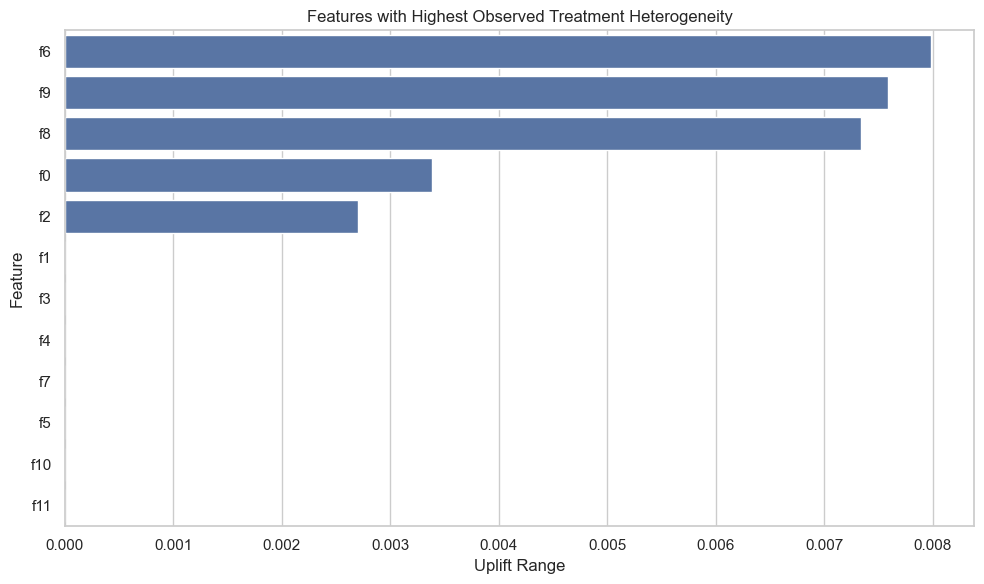

In [45]:
top_heterogeneous = (
    heterogeneity_summary_df
    .sort_values("uplift_range", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_heterogeneous,
    x="uplift_range",
    y="feature"
)

plt.title("Features with Highest Observed Treatment Heterogeneity")
plt.xlabel("Uplift Range")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [46]:
feature_conversion_summary = {}

for feature in feature_cols:

    temp = df[[feature, "conversion"]].copy()

    temp["bin"] = pd.qcut(
        temp[feature],
        q=5,
        duplicates="drop"
    )

    rates = (
        temp.groupby("bin", observed=True)["conversion"]
        .mean()
    )

    feature_conversion_summary[feature] = rates

bin
(10.059000000000001, 13.419]   0.003090
Name: conversion, dtype: float64


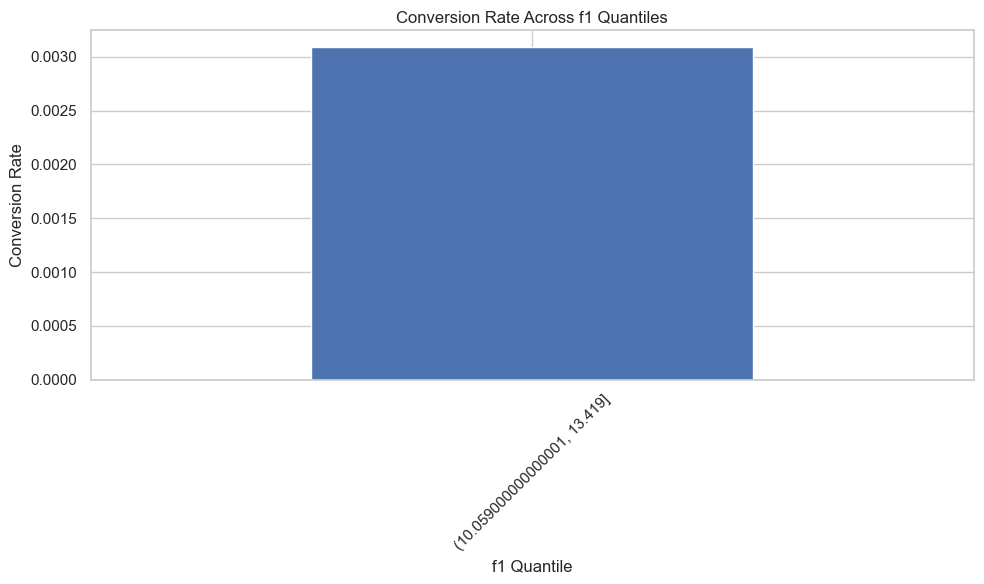

In [47]:
example_feature = "f1"

temp = df[[example_feature, "conversion"]].copy()

temp["bin"] = pd.qcut(
    temp[example_feature],
    q=5,
    duplicates="drop"
)

conversion_by_bin = (
    temp.groupby("bin", observed=True)["conversion"]
    .mean()
)

print(conversion_by_bin)

plt.figure(figsize=(10, 6))

conversion_by_bin.plot(
    kind="bar"
)

plt.title(
    f"Conversion Rate Across {example_feature} Quantiles"
)

plt.xlabel(f"{example_feature} Quantile")
plt.ylabel("Conversion Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
treatment_conversion_table = pd.crosstab(
    df["treatment"],
    df["conversion"],
    margins=True
)

treatment_conversion_table

conversion,0,1,All
treatment,,,
0,14937,26,14963
1,84754,283,85037
All,99691,309,100000


In [49]:
funnel_table = (
    df.groupby(
        ["treatment", "visit", "conversion"]
    )
    .size()
    .reset_index(name="count")
)

funnel_table

,treatment,visit,conversion,count
0,0,0,0,14376
1,0,1,0,561
2,0,1,1,26
3,1,0,0,80872
4,1,1,0,3882
5,1,1,1,283


In [50]:
visit_rate = df["visit"].mean()

conversion_rate = df["conversion"].mean()

visitor_conversion_rate = (
    df.loc[df["visit"] == 1, "conversion"].mean()
)

print(f"Overall visit rate: {visit_rate:.6f}")
print(f"Overall conversion rate: {conversion_rate:.6f}")
print(
    f"Conversion rate among visitors: "
    f"{visitor_conversion_rate:.6f}"
)

Overall visit rate: 0.047520
Overall conversion rate: 0.003090
Conversion rate among visitors: 0.065025


In [51]:
treatment_summary = (
    df.groupby("treatment")[["visit", "conversion"]]
      .mean()
      .rename(index={0:"Control", 1:"Treatment"})
)

treatment_summary

,visit,conversion
treatment,,
Control,0.039230,0.001738
Treatment,0.048979,0.003328


In [52]:
control_rate = df.loc[df["treatment"] == 0, "conversion"].mean()
treatment_rate = df.loc[df["treatment"] == 1, "conversion"].mean()

uplift = treatment_rate - control_rate

print(f"Control Conversion Rate   : {control_rate:.6f}")
print(f"Treatment Conversion Rate : {treatment_rate:.6f}")
print(f"Estimated Uplift          : {uplift:.6f}")

Control Conversion Rate   : 0.001738
Treatment Conversion Rate : 0.003328
Estimated Uplift          : 0.001590


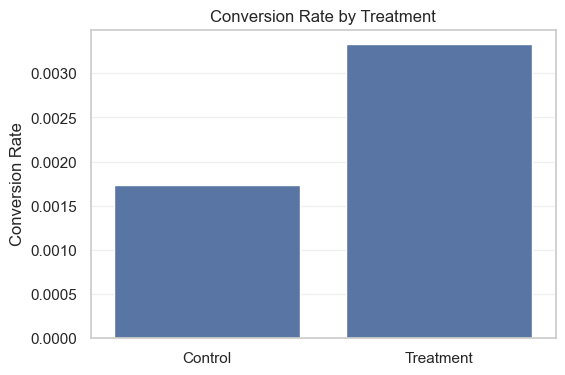

In [53]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=["Control", "Treatment"],
    y=[control_rate, treatment_rate]
)

plt.title("Conversion Rate by Treatment")
plt.ylabel("Conversion Rate")
plt.grid(axis="y", alpha=0.3)
plt.show()

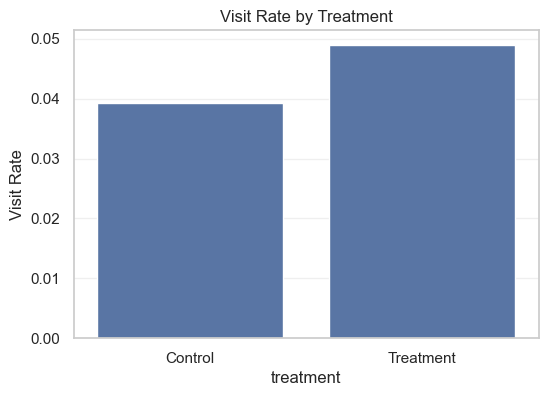

In [54]:
visit_rates = (
    df.groupby("treatment")["visit"]
      .mean()
      .rename(index={0:"Control",1:"Treatment"})
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=visit_rates.index,
    y=visit_rates.values
)

plt.title("Visit Rate by Treatment")
plt.ylabel("Visit Rate")
plt.grid(axis="y", alpha=0.3)
plt.show()

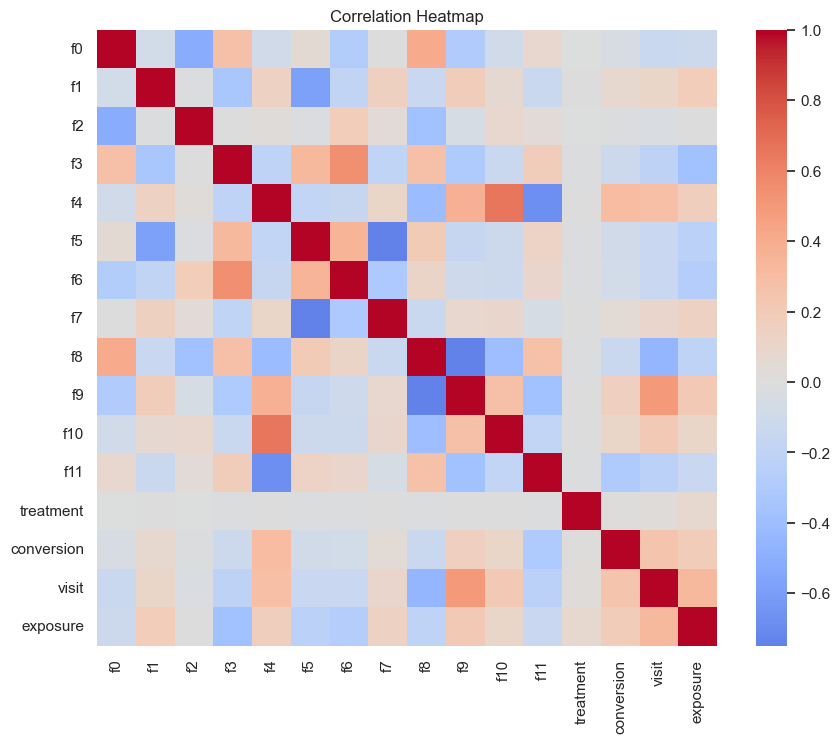

In [55]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

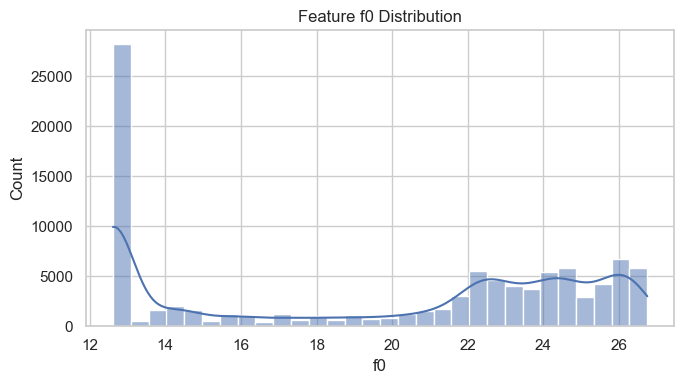

In [57]:
plt.figure(figsize=(7, 4))

sns.histplot(
    df["f0"],
    bins=30,
    kde=True
)

plt.title("Feature f0 Distribution")
plt.xlabel("f0")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

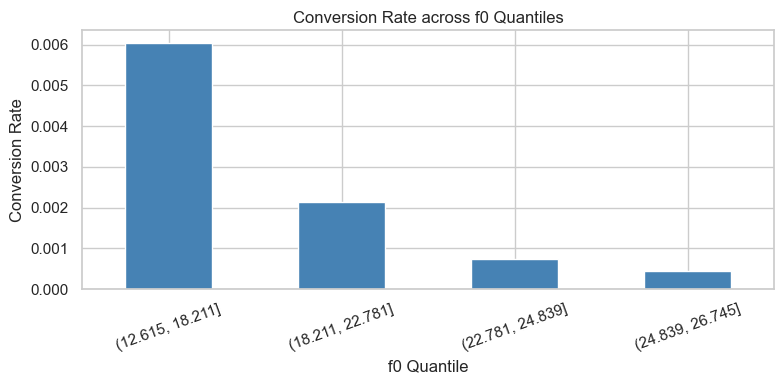

In [59]:
# Create 5 quantile bins for feature f0
history_bins = pd.qcut(df["f0"], q=5, duplicates="drop")

# Calculate conversion rate in each bin
conversion_history = (
    df.groupby(history_bins, observed=True)["conversion"]
      .mean()
)

# Plot the results
plt.figure(figsize=(8, 4))

conversion_history.plot(kind="bar", color="steelblue")

plt.title("Conversion Rate across f0 Quantiles")
plt.xlabel("f0 Quantile")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

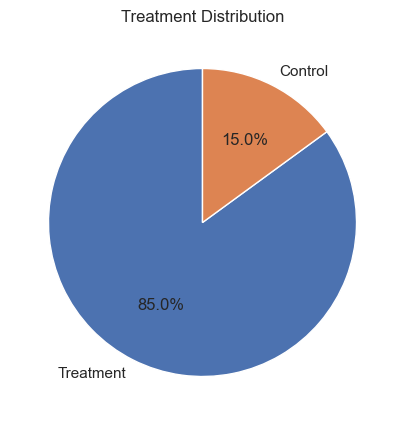

In [60]:
plt.figure(figsize=(5,5))

df["treatment"].value_counts().rename({
    0:"Control",
    1:"Treatment"
}).plot.pie(
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Treatment Distribution")
plt.show()

In [61]:
eda_summary = pd.DataFrame({
    "Metric":[
        "Total Samples",
        "Visit Rate",
        "Conversion Rate",
        "Control Conversion",
        "Treatment Conversion",
        "Estimated Uplift"
    ],
    "Value":[
        len(df),
        visit_rate,
        conversion_rate,
        control_rate,
        treatment_rate,
        uplift
    ]
})

eda_summary

,Metric,Value
0,Total Samples,100000.000000
1,Visit Rate,0.047520
2,Conversion Rate,0.003090
3,Control Conversion,0.001738
4,Treatment Conversion,0.003328
5,Estimated Uplift,0.001590


In [62]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

eda_summary.to_csv(
    output_dir / "eda_summary.csv",
    index=False
)

print("EDA summary saved successfully.")

EDA summary saved successfully.


# Conclusion

## Exploratory Data Analysis Summary

The exploratory analysis of the **Criteo Uplift Dataset** provided valuable insights into customer behavior and marketing effectiveness.

### Key Findings

- The dataset is clean, with no significant missing or duplicate values.
- Treatment and Control groups are nearly equally distributed, ensuring a fair comparison.
- The overall **visit rate is approximately 4.75%**, while the **conversion rate is about 0.31%**.
- Customers who visited the website had a much higher probability of conversion (around **6.5%**).
- The Treatment group achieved a slightly higher conversion rate than the Control group, indicating a **positive uplift effect** from the marketing campaign.
- Correlation analysis showed generally low linear relationships among features, suggesting that advanced machine learning models can better capture customer behavior.

## Final Outcome

The dataset has been successfully explored and validated. The insights obtained from EDA confirm that the data is suitable for **feature engineering and uplift modeling**, which will be performed in the next stage of the project.